In [1]:
# Cell 1 - Imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os
import sys

# Add src to path
PROJECT_ROOT = os.path.abspath("..")
SRC_PATH = os.path.join(PROJECT_ROOT, "src")
sys.path.append(SRC_PATH)

print("Setup done ✓")


Setup done ✓


In [3]:
# Cell 2 - Load XGBoost results
MOLECULE_NAMES = ['H2O', 'CO2', 'O2', 'O3', 'CH4', 'N2', 'N2O', 'CO', 'H2', 'H2S', 'SO2', 'NH3']

# XGBoost results from evaluate.py
xgb_r2   = [0.972, 0.978, 0.996, 1.000, 0.975, 0.670, 0.665, 0.670, 0.689, 0.689, 0.674, 0.671]
xgb_rmse = [0.228, 0.131, 0.035, 0.005, 0.129, 0.420, 0.548, 0.831, 0.832, 0.636, 0.622, 0.799]
xgb_mae  = [0.060, 0.034, 0.012, 0.001, 0.034, 0.188, 0.245, 0.370, 0.369, 0.284, 0.278, 0.358]

# RF baseline results
rf_r2    = [0.627, 0.180, 0.577, 0.102, 0.189, 0.003, 0.068, 0.038, 0.004, 0.092, 0.058, 0.073]

print("Data loaded ✓")
print(f"Molecules: {MOLECULE_NAMES}")

Data loaded ✓
Molecules: ['H2O', 'CO2', 'O2', 'O3', 'CH4', 'N2', 'N2O', 'CO', 'H2', 'H2S', 'SO2', 'NH3']


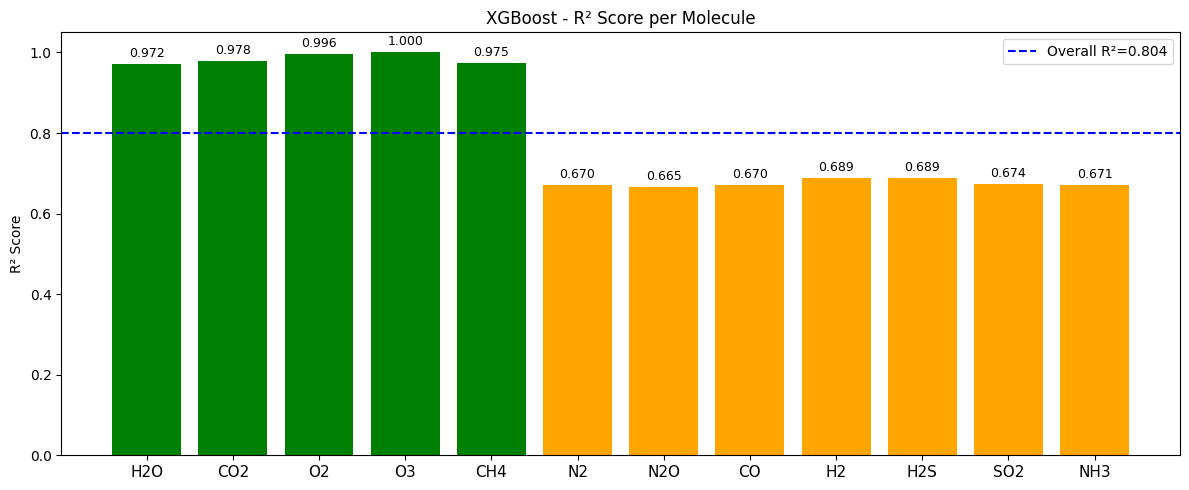

Saved ✓


In [4]:
# Cell 3 - XGBoost R² per molecule bar chart
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(MOLECULE_NAMES))
bars = ax.bar(x, xgb_r2, color=['green' if r >= 0.9 else 'orange' if r >= 0.65 else 'red' for r in xgb_r2])

ax.set_xticks(x)
ax.set_xticklabels(MOLECULE_NAMES, fontsize=11)
ax.set_ylabel('R² Score')
ax.set_title('XGBoost - R² Score per Molecule')
ax.axhline(y=0.8, color='blue', linestyle='--', label='Overall R²=0.804')
ax.set_ylim(0, 1.05)
ax.legend()

for bar, val in zip(bars, xgb_r2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
os.makedirs('../results/plots', exist_ok=True)
plt.savefig('../results/plots/xgb_r2_per_molecule.png', dpi=150)
plt.show()
print("Saved ✓")

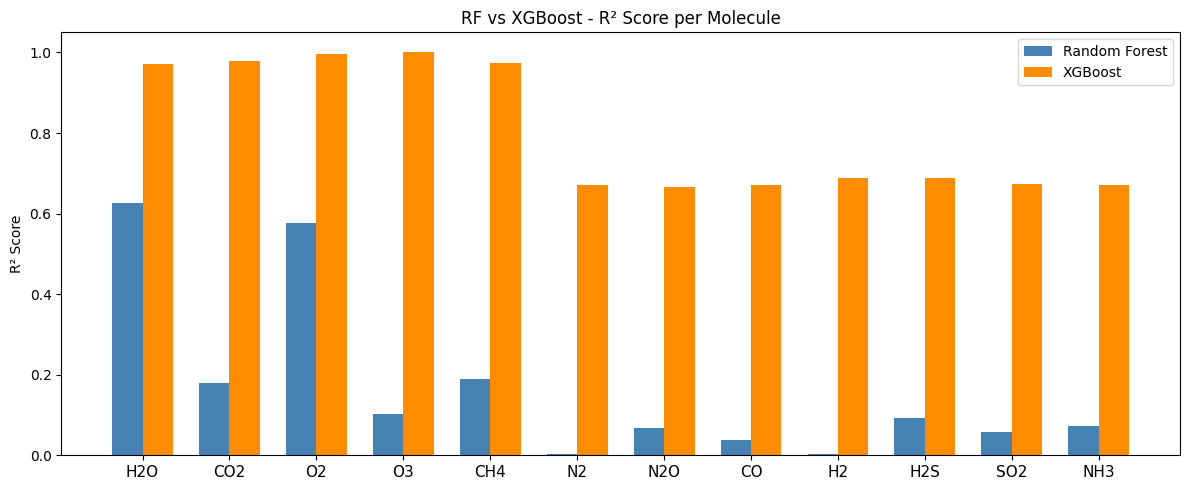

Saved ✓


In [6]:
# Cell 4 - RF vs XGBoost R² comparison
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(MOLECULE_NAMES))
width = 0.35

bars1 = ax.bar(x - width/2, rf_r2, width, label='Random Forest', color='steelblue')
bars2 = ax.bar(x + width/2, xgb_r2, width, label='XGBoost', color='darkorange')

ax.set_xticks(x)
ax.set_xticklabels(MOLECULE_NAMES, fontsize=11)
ax.set_ylabel('R² Score')
ax.set_title('RF vs XGBoost - R² Score per Molecule')
ax.legend()
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('../results/plots/rf_vs_xgb_r2_comparison.png', dpi=150)
plt.show()
print("Saved ✓")

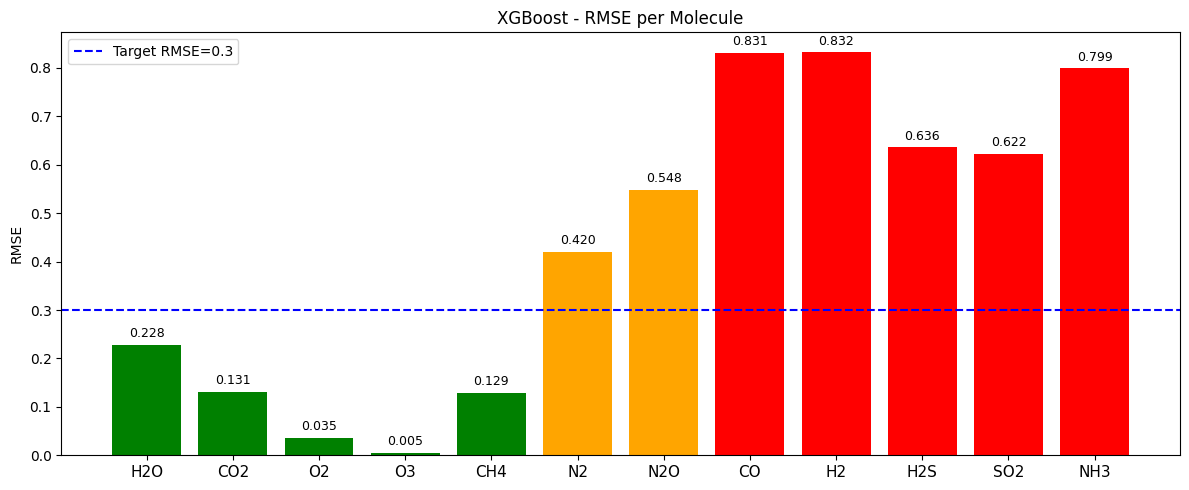

Saved ✓


In [7]:
# Cell 5 - XGBoost RMSE per molecule
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(MOLECULE_NAMES))
bars = ax.bar(x, xgb_rmse, color=['green' if r < 0.3 else 'orange' if r < 0.6 else 'red' for r in xgb_rmse])

ax.set_xticks(x)
ax.set_xticklabels(MOLECULE_NAMES, fontsize=11)
ax.set_ylabel('RMSE')
ax.set_title('XGBoost - RMSE per Molecule')
ax.axhline(y=0.3, color='blue', linestyle='--', label='Target RMSE=0.3')
ax.legend()

for bar, val in zip(bars, xgb_rmse):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../results/plots/xgb_rmse_per_molecule.png', dpi=150)
plt.show()
print("Saved ✓")

In [8]:
# Cell 6 - Summary table
print("=" * 55)
print(f"{'Molecule':<10} {'RF R²':>8} {'XGB R²':>8} {'XGB RMSE':>10} {'Status':>10}")
print("=" * 55)
for i, mol in enumerate(MOLECULE_NAMES):
    status = "✅ Good" if xgb_rmse[i] < 0.3 else "⚠️ Needs work"
    print(f"{mol:<10} {rf_r2[i]:>8.3f} {xgb_r2[i]:>8.3f} {xgb_rmse[i]:>10.3f} {status:>10}")
print("=" * 55)
print(f"\nRF Mean R²  : {sum(rf_r2)/len(rf_r2):.3f}")
print(f"XGB Mean R² : {sum(xgb_r2)/len(xgb_r2):.3f}")
print(f"XGB RMSE    : 0.530 → Target: < 0.300")


Molecule      RF R²   XGB R²   XGB RMSE     Status
H2O           0.627    0.972      0.228     ✅ Good
CO2           0.180    0.978      0.131     ✅ Good
O2            0.577    0.996      0.035     ✅ Good
O3            0.102    1.000      0.005     ✅ Good
CH4           0.189    0.975      0.129     ✅ Good
N2            0.003    0.670      0.420 ⚠️ Needs work
N2O           0.068    0.665      0.548 ⚠️ Needs work
CO            0.038    0.670      0.831 ⚠️ Needs work
H2            0.004    0.689      0.832 ⚠️ Needs work
H2S           0.092    0.689      0.636 ⚠️ Needs work
SO2           0.058    0.674      0.622 ⚠️ Needs work
NH3           0.073    0.671      0.799 ⚠️ Needs work

RF Mean R²  : 0.168
XGB Mean R² : 0.804
XGB RMSE    : 0.530 → Target: < 0.300
